In [1]:
import os
import glob
import json
import h5py
import numpy as np
import pandas as pd
from collections import defaultdict

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
)

# Plotting 
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# Functions for bootstrap performance estimates
def specificity(y, y_hat, pos_labels: set):
    y_bin = np.isin(y, list(pos_labels)).astype(np.uint8)
    y_hat_bin = np.isin(y_hat, list(pos_labels)).astype(np.uint8)
    return recall_score(y_bin, y_hat_bin, pos_label=0)

def binary_scores(y, y_hat, pos_labels: set):
    y_bin = np.isin(y, list(pos_labels)).astype(np.uint8)
    y_hat_bin = np.isin(y_hat, list(pos_labels)).astype(np.uint8)

    specificity = recall_score(y_bin, y_hat_bin, pos_label=0, zero_division=np.nan)
    recall = recall_score(y_bin, y_hat_bin, zero_division=np.nan)
    precision = precision_score(y_bin, y_hat_bin, zero_division=np.nan)
    f1 = f1_score(y_bin, y_hat_bin, zero_division=np.nan)
    return {
        'f1': f1, 
        'precision': precision,
        'recall': recall, 
        'specificity': specificity
    }

def get_point_metrics(y, y_hat):
    metrics = dict()
    
    # Class-wise metrics
    metrics['f1'] = f1_score(y, y_hat, average=None, zero_division=np.nan, labels=[0,1,2,3])
    metrics['precision'] = precision_score(y, y_hat, average=None, zero_division=np.nan, labels=[0,1,2,3])
    metrics['recall'] = recall_score(y, y_hat, average=None, zero_division=np.nan, labels=[0,1,2,3])

    # Overall metrics
    metrics['accuracy'] = accuracy_score(y, y_hat)
    metrics['f1_macro'] = f1_score(y, y_hat, average='macro', zero_division=np.nan, labels=[0,1,2,3])
    metrics['precision_macro'] = precision_score(y, y_hat, average='macro',zero_division=np.nan, labels=[0,1,2,3])
    metrics['recall_macro'] = recall_score(y, y_hat, average='macro',zero_division=np.nan, labels=[0,1,2,3])

    # Binary aggregated class metrics
    metrics['severe_bin'] = binary_scores(y, y_hat, pos_labels=set([3]))
    metrics['mod_to_sev_bin'] = binary_scores(y, y_hat, pos_labels=set([2,3]))
    metrics['mild_to_sev_bin'] = binary_scores(y, y_hat, pos_labels=set([1,2,3]))

    metrics = pd.concat({key: pd.Series(value) for key, value in metrics.items()})
    return metrics

def bootstrap_metrics(y, y_hat, n_boot):
    point_metrics = get_point_metrics(y, y_hat)

    rng = np.random.default_rng(0)
    boot_metrics = []
    for _ in range(n_boot):
        boot_idx = rng.integers(0, len(y), len(y))
    
        boot_metrics.append(get_point_metrics(y[boot_idx], y_hat[boot_idx]))

    boot_metrics = pd.DataFrame(boot_metrics)    
    return pd.DataFrame({
        'estimate': point_metrics,
        'lower_ci': boot_metrics.quantile(0.025),
        'upper_ci': boot_metrics.quantile(0.975),
    })

In [3]:
# Functions to extract summary features from the AcceleRest predictions
from scipy.stats import kurtosis, skew

def get_summary_stats(signal, signal_name, results):
    results[f'Mean {signal_name}'] = np.mean(signal)
    results[f'{signal_name} Var'] = np.var(signal)
    results[f'Max {signal_name}'] = np.max(signal)
    results[f'Min {signal_name}'] = np.min(signal)
    p10, p25, med, p75, p90 = np.percentile(signal, [10, 25, 50, 75, 90])
    results[f'{signal_name} P10'] = p10
    results[f'{signal_name} P25'] = p25
    results[f'{signal_name} Median'] = med
    results[f'{signal_name} P75'] = p75
    results[f'{signal_name} P90'] = p90
    results[f'{signal_name} Kurtosis'] = kurtosis(signal, bias=True)
    results[f'{signal_name} Skew'] = skew(signal, bias=True)
    return results

def get_apnea_features_3c(subject_path):
    scores = np.load(os.path.join(subject_path, 'soft_preds.npy'))
    preds = scores.argmax(axis=-1)
    results = {}
    results['HAR'] = (preds == 1).sum()/len(preds)
    results['OAR'] = (preds == 2).sum()/len(preds)
    re = np.logical_or(preds == 1, preds == 2)
    results['RER'] = re.mean() # N events/total recording time
    results['RETCR'] = np.diff(re).mean() # Threshold crossing rate
    re_p = scores[:, 1:].sum(-1)
    results = get_summary_stats(re_p, 'REP', results)
    return results

def get_apnea_features_2c(subject_path):
    scores = np.load(os.path.join(subject_path, 'soft_preds.npy'))
    preds = scores.argmax(axis=-1)
    results = {}
    re = preds == 1
    results['RER'] = re.mean()
    results['RETCR'] = np.diff(re).mean()
    # results['RE (N)'] = (p).sum()/len(preds)
    re_p = scores[:, 1]
    results = get_summary_stats(re_p, 'REP', results)
    return results

def get_apnea_features_reg(subject_path):
    preds = np.load(os.path.join(subject_path, 'preds.npy'))
    results = {}
    results = get_summary_stats(preds, 'RER', results)
    return results

def get_sleep_features(ss_results_path):
    ss_targets = np.load(os.path.join(ss_results_path, 'targets.npy'))
    ss_scores = np.load(os.path.join(ss_results_path, 'soft_preds.npy'))
    ss_preds = ss_scores.argmax(-1) 
    results = {}
    ss_label_map = {
        0: 'Deep',
        1: 'Light',
        2: 'REM',
        3: 'Wake',
        -9: 'Missing',
    }
    for k in range(ss_scores.shape[-1]):
        stage = ss_label_map[k]
        results[f'{stage} (%)'] = (ss_preds == k).sum()/len(ss_preds)
        results[f'{stage} (Pr)'] = ss_scores[:, k].mean()
        results = get_summary_stats(ss_scores[:, k], f'{stage} (Pr)', results)

    results[f'Sleep (%)'] = sum([(ss_preds == k).sum() for k in [0,1,2]])/len(ss_preds)
    results[f'Sleep (Pr)'] = ss_scores[:, :-1].sum(-1).mean()
    results = get_summary_stats(ss_scores[:, :-1].sum(-1), 'Sleep (Pr)', results)
    tm = get_state_transitions(ss_preds, ss_scores.shape[-1])
    for fro, to in np.ndindex(tm.shape):
        results[f'{ss_label_map[fro]} → {ss_label_map[to]}'] = tm[fro, to]
    return results
    
def get_state_transitions(preds, n_classes):
    fro = preds[:-1]
    to = preds[1:]
    counts = np.zeros((n_classes, n_classes))
    np.add.at(counts, (fro, to), 1)
    probs = counts / (counts.sum(axis=1, keepdims=True) + 1e-3)
    return probs

def get_apnea_sleep_interactions(apnea_path, ss_path):
    apnea_scores = np.load(os.path.join(apnea_path, 'soft_preds.npy'))
    apnea_preds = apnea_scores.argmax(-1)

    ss_scores = np.load(os.path.join(ss_path, 'soft_preds.npy'))
    ss_preds = ss_scores.argmax(-1)
    ss_label_map = {
        0: 'Deep',
        1: 'Light',
        2: 'REM',
        3: 'Wake',
        -9: 'Missing',
    }
    results = {}
    for k in range(ss_scores.shape[-1]):
        # RER = Respiratory event rate
        # AREP = Average Respiratory Event Probablitiy
        # REPC = Respiratory event probablility correaltion
        stage = ss_label_map[k]
        stage_epochs = ss_preds == k
        if (stage_epochs).sum() > 0:
            results[f'{stage} RER'] = (apnea_preds[stage_epochs] == 1).sum() / (stage_epochs).sum()
            results[f'{stage} Mean REP'] = apnea_scores[stage_epochs, 1].mean()
        else:
            results[f'{stage} RER'] = np.nan
            results[f'{stage} Mean REP'] = np.nan
        results[f'{stage} REP Corr'] = np.corrcoef(ss_scores[:,k], apnea_scores[:, 1])[0,1]

        # Get indeces 2 epochs beofre and 1 epoch after onsets and offsets
        onsets = np.argwhere(np.diff(stage_epochs.astype(int)) == 1)
        onsets = np.concatenate([onsets, onsets-1, onsets-2, onsets+1])
        onsets = onsets[np.logical_and(onsets > 0, onsets < len(ss_preds))]
        results[f'{stage} Onset REP'] = apnea_scores[onsets, 1].mean()

        offsets = np.argwhere(np.diff(stage_epochs.astype(int)) == -1)
        offsets = np.concatenate([offsets, offsets-1, offsets-2, offsets+1])
        offsets = offsets[np.logical_and(offsets > 0, offsets < len(ss_preds))]
        results[f'{stage} Offset REP'] = apnea_scores[offsets, 1].mean()
    
    sleep_epochs = ss_preds != 3
    results[f'Sleep RER'] = (apnea_preds[sleep_epochs] == 1).sum() / (sleep_epochs).sum()    
    results[f'Sleep Mean REP'] = apnea_scores[sleep_epochs, 1].mean()
    results[f'Sleep REP Corr'] = np.corrcoef(ss_scores[:,:3].sum(-1), apnea_scores[:, 1])[0,1]
    return results

In [4]:
# Function to exctract and structure results from the datasets
def get_results(experiments: dict, interactions: str = None):
    data_paths = {
        'tbi': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/tbi/',
        'amazfit': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/amazfit/',
        'dreamt': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/dreamt/',
        'stages': '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/stages/',
    }

    results_super = {}
    for exp_name, model_dict in experiments.items():
        for model_name, results_dir in model_dict.items():
            results_super[f'{exp_name} {model_name}'] = defaultdict(list)
            if interactions is not None and exp_name != interactions:
                results_super[f'{exp_name} - {interactions} {model_name}'] = defaultdict(list)
                interact_base = experiments[interactions][model_name]
            
            for dataset in os.scandir(results_dir):
                if os.path.basename(dataset) not in data_paths.keys():
                    continue
                for sub_dir in os.scandir(dataset):
                    results_super[f'{exp_name} {model_name}']['subject'].append(os.path.basename(sub_dir))
                    results_super[f'{exp_name} {model_name}']['dataset'].append(os.path.basename(dataset))

                    # Get subject AHI from data file
                    sub_h5 = data_paths[os.path.basename(dataset)] + os.path.basename(sub_dir) + '.h5'
                    with h5py.File(sub_h5, 'r') as f:
                        results_super[f'{exp_name} {model_name}']['AHI'].append(f.attrs['ahi'])
                    
                    # Get apnea / sleep stage estimation summary features from model outputs
                    if exp_name in ['Three-Class', 'Precision']:
                        features = get_apnea_features_3c(sub_dir.path)
                    elif exp_name == 'Two-Class':
                        features = get_apnea_features_2c(sub_dir.path)
                    elif exp_name == 'Regression':
                        features = get_apnea_features_reg(sub_dir.path)
                    elif exp_name == 'Sleep Stages':
                        features = get_sleep_features(sub_dir.path)
                    
                    for feature, val in features.items():
                        results_super[f'{exp_name} {model_name}'][feature].append(val)
                    
                    if interactions is not None and exp_name != interactions:
                        interact_path = os.path.join(interact_base, os.path.basename(dataset), os.path.basename(sub_dir))
                        interaction_features = get_apnea_sleep_interactions(sub_dir.path, interact_path)
                        for feature, val in interaction_features.items():
                            results_super[f'{exp_name} - {interactions} {model_name}'][feature].append(val)
                        
                        results_super[f'{exp_name} - {interactions} {model_name}']['subject'].append(os.path.basename(sub_dir))
                        results_super[f'{exp_name} - {interactions} {model_name}']['dataset'].append(os.path.basename(dataset))

            results_super[f'{exp_name} {model_name}'] = pd.DataFrame(results_super[f'{exp_name} {model_name}'])
            if interactions is not None and exp_name != interactions:
                results_super[f'{exp_name} - {interactions} {model_name}'] = pd.DataFrame(results_super[f'{exp_name} - {interactions} {model_name}'])
    return results_super

In [5]:
experiments_final = {
    'Two-Class': {
        'Test set': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/mae_bwm_apnea_2c_internal',
        'Train set': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/mae_bwm_apnea_2c_internal_train',
        'External test': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/mae_bwm_apnea_2c_external',
    },
    'Sleep Stages': {
        'Test set': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal',
        'Train set': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal_train',
        'External test': '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external'
    },
}

In [6]:
# Get datasets for final model testing
results_super = get_results(experiments_final, interactions = 'Sleep Stages')

/tmp/ipykernel_25086/402448830.py:116: RuntimeWarning: Mean of empty slice.
  results[f'{stage} Onset REP'] = apnea_scores[onsets, 1].mean()
/home/groups/mignot/nielsl/environments/torch_surv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_25086/402448830.py:121: RuntimeWarning: Mean of empty slice.
  results[f'{stage} Offset REP'] = apnea_scores[offsets, 1].mean()


In [7]:
# Define training and test partitionts
apnea_test_results = results_super['Two-Class Test set'].copy().sort_values('subject')
sleep_test_results = results_super['Sleep Stages Test set'].copy().sort_values('subject')
interaction_test_results = results_super['Two-Class - Sleep Stages Test set'].copy().sort_values('subject')

apnea_train_results = results_super['Two-Class Train set'].copy().sort_values('subject')
sleep_train_results =  results_super['Sleep Stages Train set'].copy().sort_values('subject')
interaction_train_results = results_super['Two-Class - Sleep Stages Train set'].copy().sort_values('subject')

apnea_external_test_results = results_super['Two-Class External test'].copy().sort_values('subject')
sleep_external_test_results = results_super['Sleep Stages External test'].copy().sort_values('subject')
interaction_external_test_results = results_super['Two-Class - Sleep Stages External test'].copy().sort_values('subject')

bins = [0, 5, 15, 30, np.inf]
apnea_test_results['OSA severity'] = np.digitize(apnea_test_results['AHI'], bins=bins, right=False) - 1
apnea_train_results['OSA severity'] = np.digitize(apnea_train_results['AHI'], bins=bins, right=False) - 1
apnea_external_test_results['OSA severity'] = np.digitize(apnea_external_test_results['AHI'], bins=bins, right=False) - 1

train = apnea_train_results.merge(sleep_train_results, on = ['subject', 'dataset', 'AHI'],
).merge(interaction_train_results, on = ['subject', 'dataset'],
).drop(columns=['subject', 'dataset', 'AHI'])

int_test = apnea_test_results.merge(sleep_test_results, on = ['subject', 'dataset', 'AHI'],
).merge(interaction_test_results, on = ['subject', 'dataset'],
).drop(columns=['subject', 'dataset', 'AHI'])

ext_test = apnea_external_test_results.merge(sleep_external_test_results, on = ['subject', 'dataset', 'AHI']
).merge(interaction_external_test_results, on = ['subject', 'dataset']
).drop(columns=['subject', 'dataset', 'AHI'])

In [8]:
# Specify estimator and Parameter grid
seed = 0

estimator = RandomForestClassifier(
    n_estimators=250,
    random_state=seed,
    class_weight='balanced_subsample',
    n_jobs=-1,
)

grid = {
    'max_depth': [5, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'max_samples': [0.6, None],
    'max_features': [5, 'sqrt'],
}
print("grid size:", len(ParameterGrid(grid)))

# Run grid search cross validation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)

y_train = train['OSA severity']
x_train = train.drop(columns=['OSA severity'])

gridsearch = GridSearchCV(
        estimator=estimator, 
        param_grid=grid, 
        scoring=['accuracy', 'f1_macro'], 
        cv=cv, 
        refit=False,
)

path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/code/AcceleRest/notebooks/apnea/'
filename = 'gridsearch_cv_results.csv'
save_to = os.path.join(path, filename)
if os.path.exists(save_to):
    cv_results = pd.read_csv(save_to)
else:
    gridsearch.fit(x_train, y_train)
    cv_results = pd.DataFrame(gridsearch.cv_results_).sort_values(by=['rank_test_f1_macro', 'rank_test_accuracy'], inplace=False)
    cv_results.to_csv(save_to)

print(cv_results.loc[cv_results['rank_test_f1_macro'] == 1])

grid size: 32
   Unnamed: 0  mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0          14       0.678624      0.013941         0.026783        0.001400   
1          15       0.671595      0.013132         0.026689        0.001335   

   param_max_depth param_max_features  param_max_samples  \
0              5.0               sqrt                NaN   
1              5.0               sqrt                NaN   

   param_min_samples_leaf  param_min_samples_split  ... split18_test_f1_macro  \
0                       5                        2  ...              0.478581   
1                       5                        5  ...              0.478581   

   split19_test_f1_macro  split20_test_f1_macro  split21_test_f1_macro  \
0               0.533577               0.560274               0.479124   
1               0.533577               0.560274               0.479124   

   split22_test_f1_macro  split23_test_f1_macro  split24_test_f1_macro  \
0               0.600071  

In [9]:
#Fit final model in repeated 5-fold cv on train partition
rf = RandomForestClassifier(
    criterion='gini',
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features='sqrt',
    max_samples=None,
    class_weight='balanced_subsample',
    random_state=0,
    n_jobs=-1,
)


k_folds = 5
n_repeats = 5
cv = RepeatedStratifiedKFold(n_splits=k_folds, n_repeats=n_repeats, random_state=seed)
fold_metrics = []
for train_idx, val_idx in cv.split(x_train, y_train):
    y_train_ = y_train.loc[train_idx]
    x_train_ = x_train.loc[train_idx]

    rf = rf.fit(x_train_, y_train_)

    y_val = y_train.loc[val_idx]
    x_val = x_train.loc[val_idx]

    y_hat_val = rf.predict(x_val)

    fold_metrics.append(get_point_metrics(y_hat_val, y_val))

fold_metrics = pd.DataFrame(fold_metrics)

In [10]:
from scipy.stats import t

# Calculate confidence intervals using the corrected repeated k-fold t interval (Nadeau–Bengio correction)
se = np.sqrt((1 / (k_folds * n_repeats) + 1 / (k_folds - 1)) * fold_metrics.var())
q = t.ppf(1 - 0.05 / 2, df=n_repeats - 1)

val_metrics = pd.DataFrame({
'estimate': fold_metrics.mean(),
'lower_ci': fold_metrics.mean() - q *se,
'upper_ci': fold_metrics.mean() + q *se,
}).round(3) * 100

In [11]:
#Fit final model on train partition
rf = RandomForestClassifier(
    criterion='gini',
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features='sqrt',
    max_samples=None,
    class_weight='balanced_subsample',
    random_state=0,
    n_jobs=-1,
)

rf = rf.fit(x_train, y_train)

# Test on internal test
y_int_test = int_test['OSA severity']
x_int_test = int_test.drop(columns=['OSA severity'])

y_hat_int_test = rf.predict(x_int_test)#[top_features])

# Test on external test
y_ext_test = ext_test['OSA severity']
x_ext_test = ext_test.drop(columns=['OSA severity'])

y_hat_ext_test = rf.predict(x_ext_test)#[top_features])

In [12]:
# Bootstrap metrics
int_metrics = bootstrap_metrics(y_int_test, y_hat_int_test, n_boot=1000)
ext_metrics = bootstrap_metrics(y_ext_test, y_hat_ext_test, n_boot=1000)
comb_metrics = bootstrap_metrics(np.concat([y_int_test,y_ext_test],axis=0),np.concat([y_hat_int_test,y_hat_ext_test],axis=0), n_boot=1000)

In [22]:
comb_metrics.round(3) * 100

estimate  lower_ci  upper_ci
f1              0                59.3      48.3      69.0
                1                49.6      38.3      60.0
                2                35.7      19.5      51.4
                3                62.9      42.8      80.0
precision       0                64.0      51.9      76.2
                1                50.0      37.1      61.8
                2                29.4      14.7      44.4
                3                68.8      46.2      90.9
recall          0                55.2      41.8      67.3
                1                49.2      37.0      61.7
                2                45.5      25.0      66.7
                3                57.9      35.3      78.9
accuracy        0                51.9      44.4      59.4
f1_macro        0                51.9      43.8      59.5
precision_macro 0                53.0      45.3      60.9
recall_macro    0                51.9      43.6      60.4
severe_bin      f1               62.9      42.8      80.0
                precision        68.8      46.2      90.9
                recall           57.9      35.3      78.9
                specificity      96.5      93.1      99.3
mod_to_sev_bin  f1               59.3      46.4      70.4
                precision        54.0      40.0      66.7
                recall           65.9      52.2      80.4
                specificity      80.7      73.3      87.3
mild_to_sev_bin f1               79.2      73.3      84.7
                precision        76.4      68.5      83.7
                recall           82.4      74.3      89.4
                specificity      55.2      41.8      67.3

In [13]:
comb_df = (
    comb_metrics.loc[['severe_bin','mod_to_sev_bin','mild_to_sev_bin']].round(3) * 100
).reset_index()
comb_df['Partition'] = 'Combined Test'

ext_df = (
    ext_metrics.loc[['severe_bin','mod_to_sev_bin','mild_to_sev_bin']].round(3) * 100
).reset_index()
ext_df['Partition'] = 'External Test'

int_df = (
    int_metrics.loc[['severe_bin','mod_to_sev_bin','mild_to_sev_bin']].round(3) * 100
).reset_index()
int_df['Partition'] = 'Internal Test'

val_df = val_metrics.loc[['severe_bin','mod_to_sev_bin','mild_to_sev_bin']].reset_index()
val_df['Partition'] = 'Cross-validation'

all_df = pd.concat([comb_df, ext_df, int_df, val_df], ignore_index=True).rename(
    columns={
        'level_0': 'Severity',
        'level_1': 'Metric',
        'estimate': 'Estimate',
    }
)

all_df['Severity'] = all_df['Severity'].map({
    'severe_bin': 'Severe',
    'mod_to_sev_bin': 'Moderate to Severe',
    'mild_to_sev_bin': 'Mild to Severe',
})

/tmp/ipykernel_25086/16246198.py:15: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_25086/16246198.py:15: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_25086/16246198.py:15: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_25086/16246198.py:15: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.barplot(


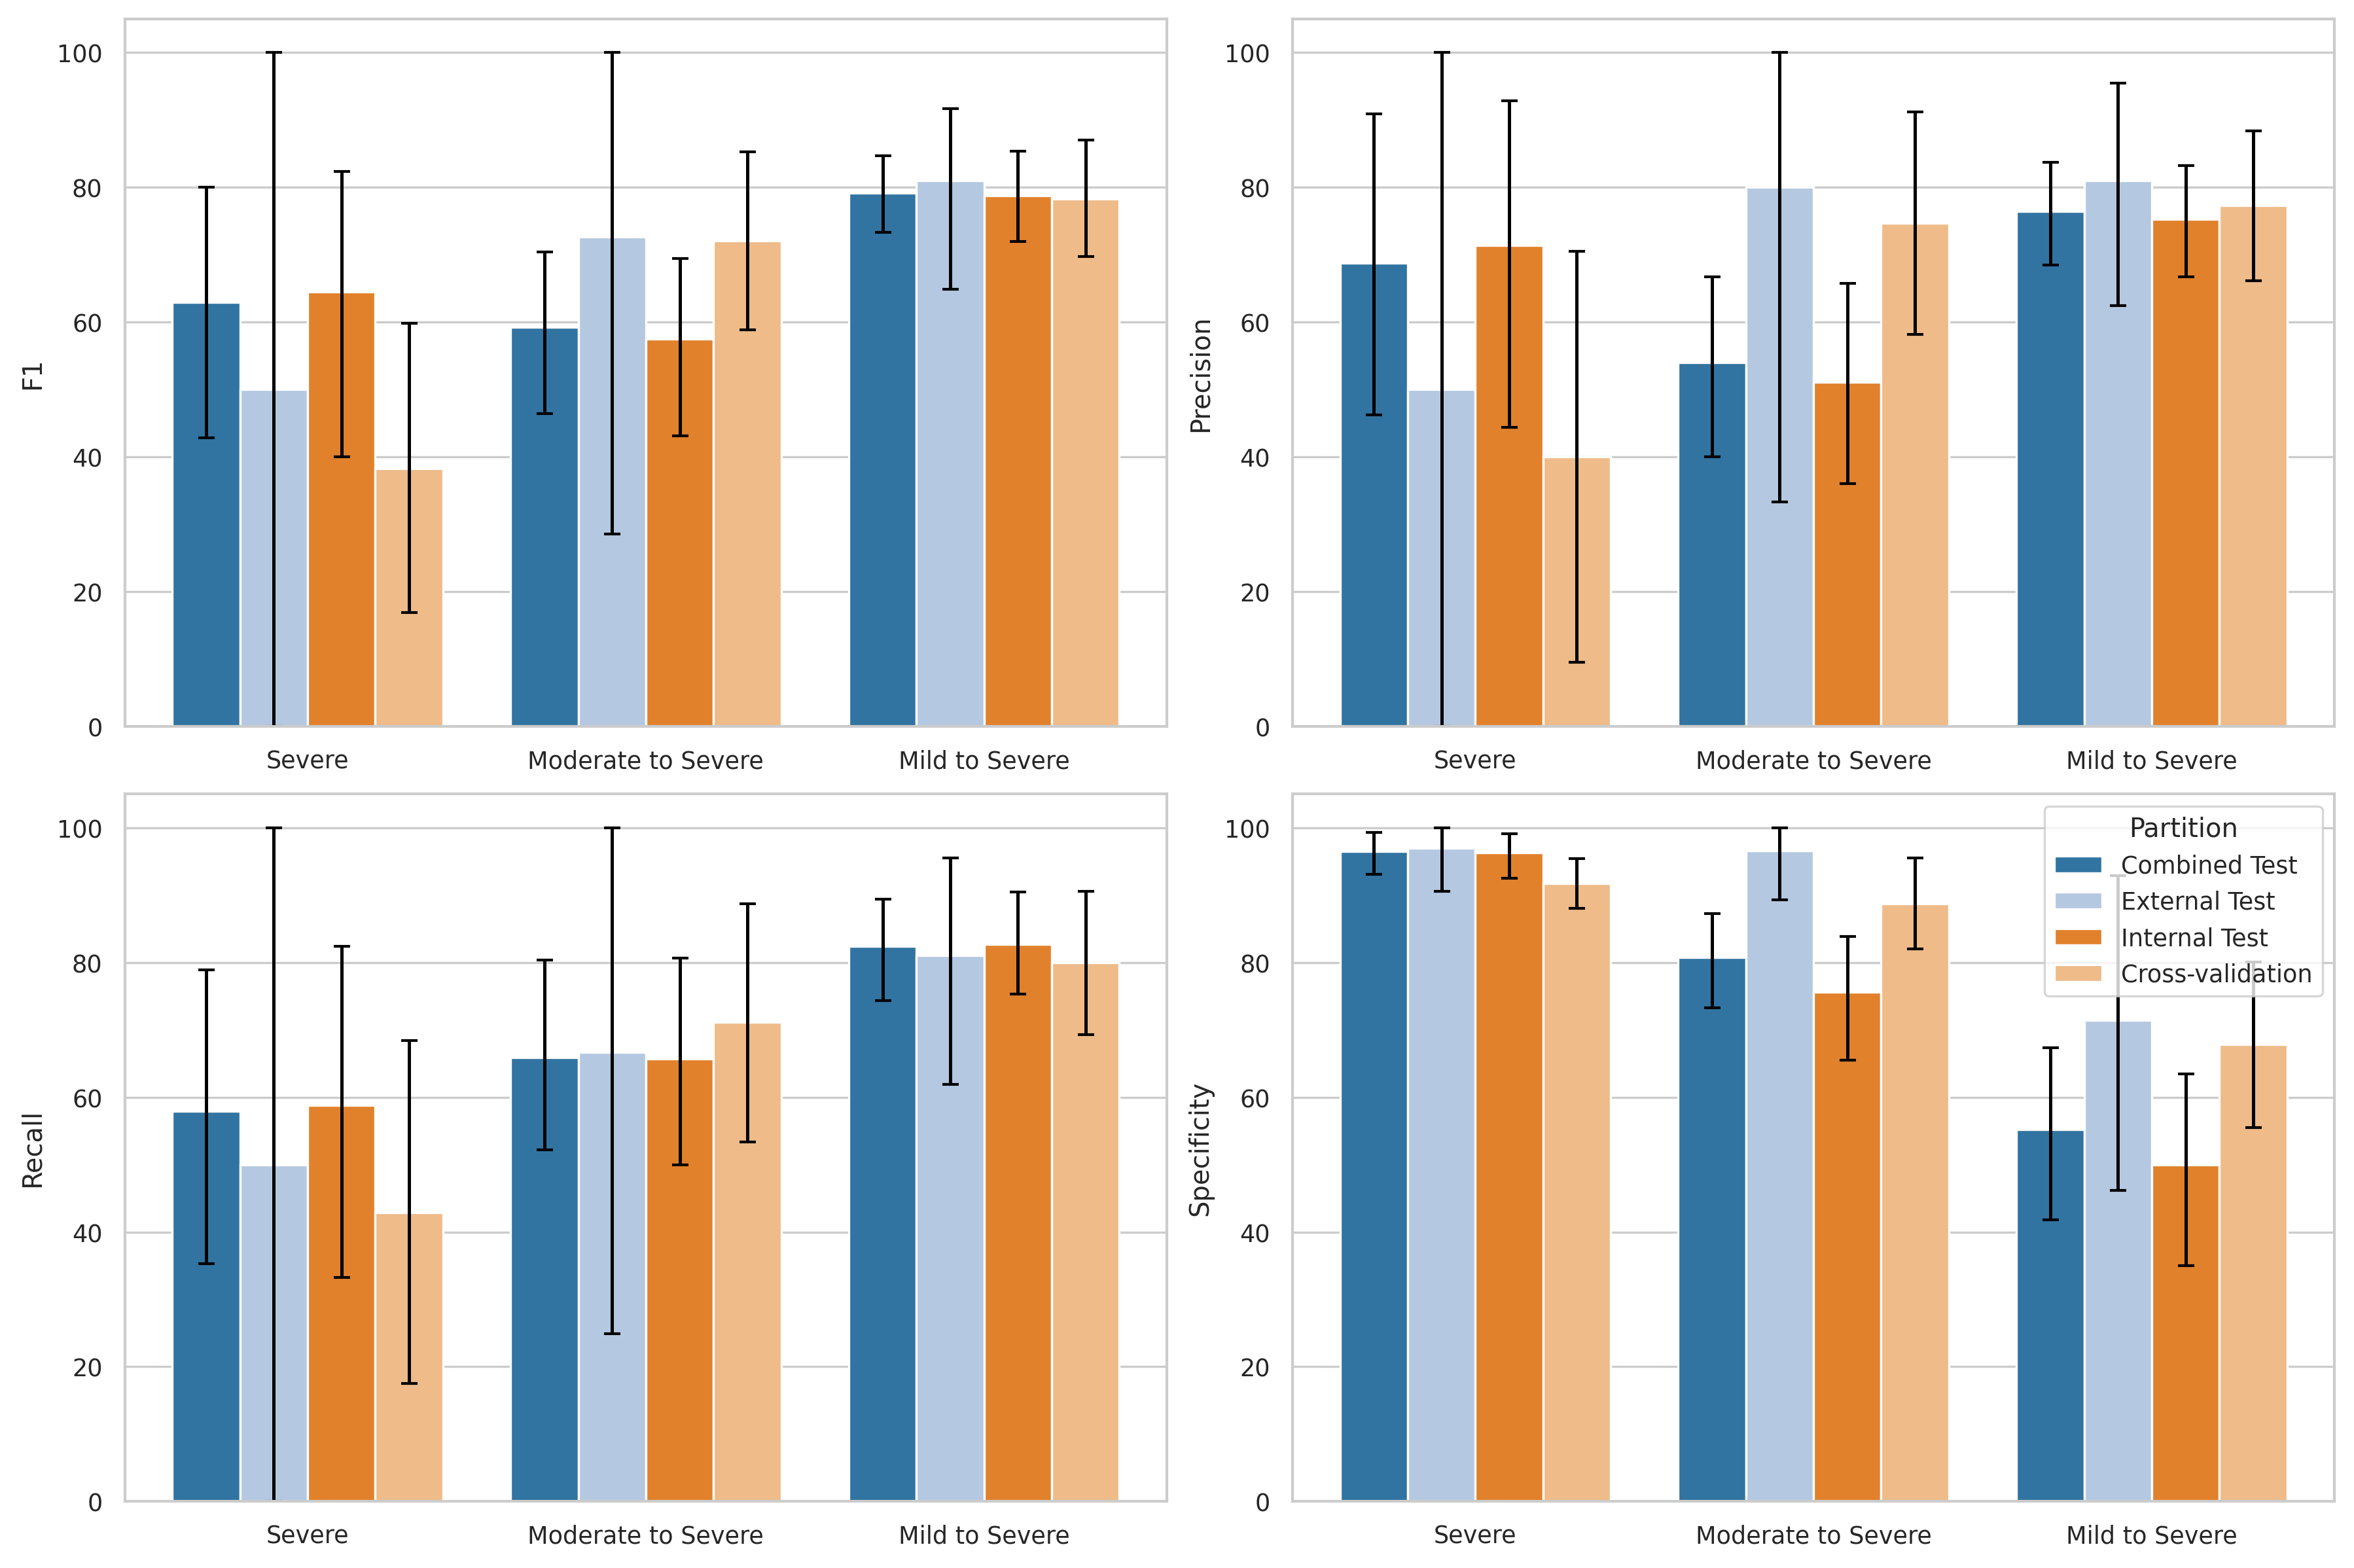

In [14]:
sns.set_context("paper")
sns.set_style('whitegrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

metrics = ['f1', 'precision', 'recall', 'specificity']
severity_order = ['Severe', 'Moderate to Severe', 'Mild to Severe']
partition_order = ['Combined Test', 'External Test', 'Internal Test', 'Cross-validation']

fig, axs = plt.subplots(2, 2, figsize=(12, 8), dpi=300)

for metric, ax in zip(metrics, axs.flat):
    data = all_df[all_df['Metric'] == metric]

    sns.barplot(
        data=data, x='Severity', y='Estimate', hue='Partition',
        order=severity_order, hue_order=partition_order,
        errorbar=None, ax=ax, palette=sns.color_palette("tab20"),
    )

    for container, partition in zip(ax.containers, partition_order):
        d = (
            data[data['Partition'] == partition]
            .set_index('Severity')
            .reindex(severity_order)
        )

        for bar, (_, row) in zip(container, d.iterrows()):
            ax.errorbar(
                bar.get_x() + bar.get_width()/2,
                row['Estimate'],
                yerr=[[row['Estimate'] - row['lower_ci']],
                      [row['upper_ci'] - row['Estimate']]],
                fmt='none', color='black', capsize=3
            )

    ax.set_ylabel(metric.capitalize())
    # ax.set_title(metric)
    ax.set_xlabel('')

for ax in axs.flat[:-1]:
    ax.get_legend().remove()

plt.tight_layout()

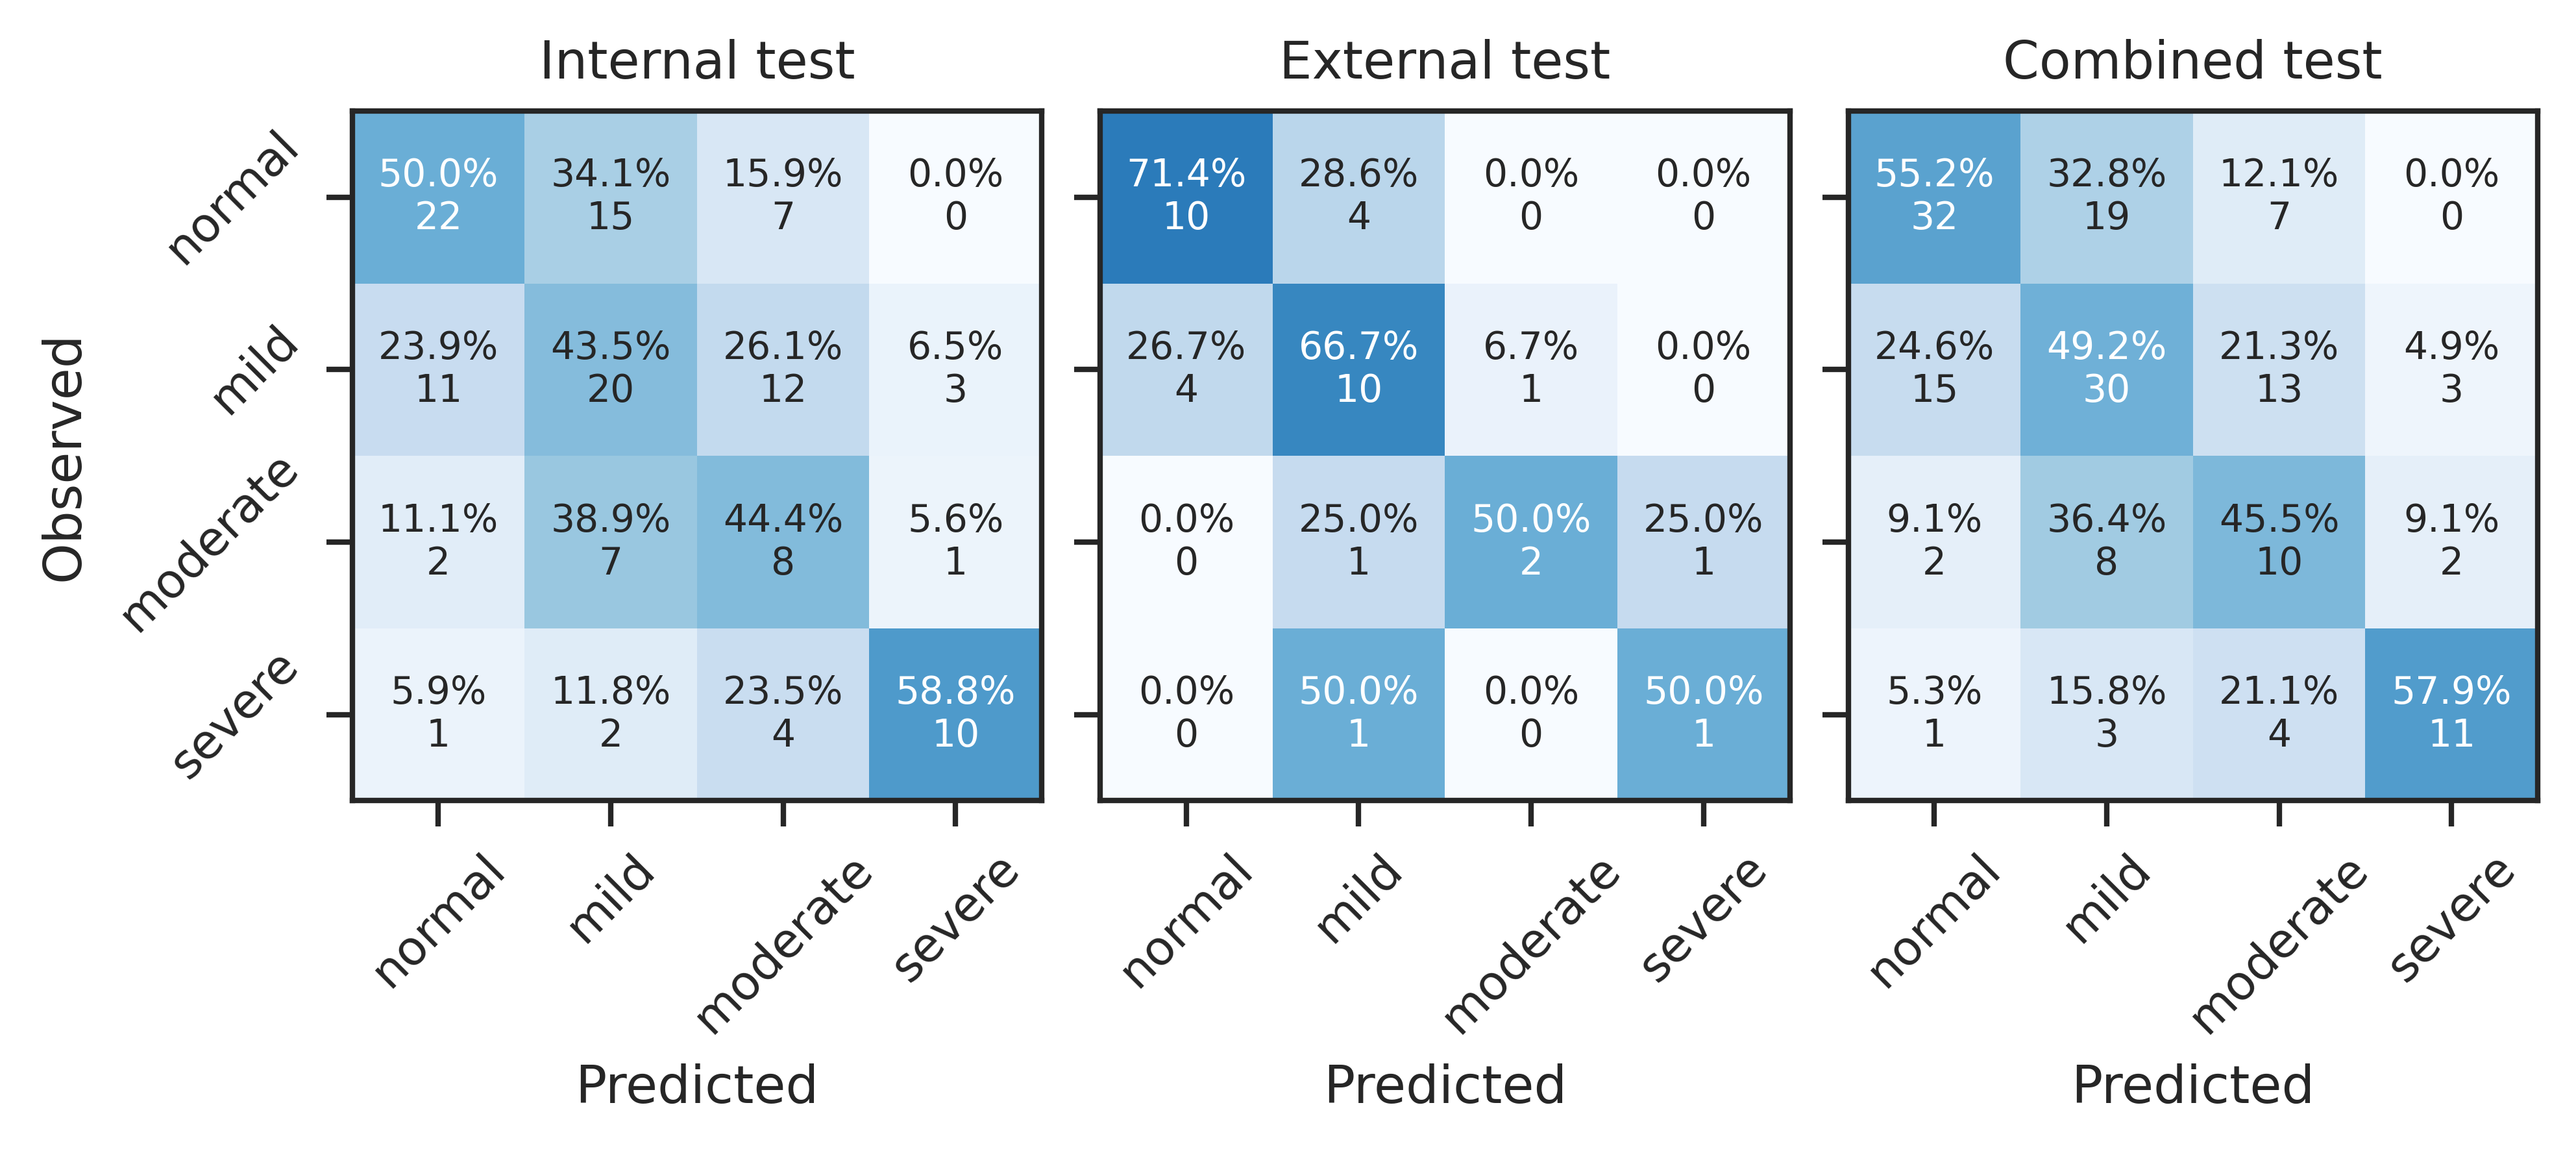

In [15]:
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

ln = ["normal", "mild", "moderate", "severe"]

fig, axes = plt.subplots(1,3,dpi=600, figsize=(6.5,3), layout='constrained',sharey=True)#, sharex=True)
y = [y_int_test, y_ext_test, np.concat([y_int_test, y_ext_test])]
y_hat = [y_hat_int_test, y_hat_ext_test, np.concat([y_hat_int_test, y_hat_ext_test])]
titles = [
    f"Internal test",#, N = {len(y_int_test)}\nF1: {100*int_stats['f1_mean']:.1f} $\pm$ {100 * int_stats['f1_std']:.1f}", 
    f"External test",#, N = {len(y_ext_test)}\nF1: {100*ext_stats['f1_mean']:.1f} $\pm$ {100 * ext_stats['f1_std']:.1f}"
    f"Combined test"
]
for i, ax in enumerate(axes):
    ## Confusion Matrix Combined
    cm_abs = confusion_matrix(y[i], y_hat[i], normalize=None)
    cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
    # Create combined annotation matrix
    annot = np.empty_like(cm_abs).astype(str)
    for r in range(cm_abs.shape[0]):
        for c in range(cm_abs.shape[1]):
            annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
    ax = sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=ax,
        square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
        xticklabels=ln, yticklabels=ln,# annot_kws={'fontsize':7}
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    
    if i == 0:
        ax.set_ylabel('Observed')
        
    ax.tick_params(rotation = 45)
    for label in ax.get_yticklabels():
        label.set_verticalalignment('center')

    ax.set_xlabel('Predicted')
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

    ax.set_title(titles[i])
# ax.set_title(f'Combined Test (N={len(y_hat_combined)}), F1={round(combined_f1.mean(0), 2)}')

In [16]:
from sklearn.inspection import permutation_importance
r = permutation_importance(rf, pd.concat([x_int_test, x_ext_test],axis=0), pd.concat([y_int_test, y_ext_test],axis=0), n_repeats=30, random_state=0)

In [17]:
feature_importance = {
    'Feature Importance': r['importances_mean'],
    'Feature': x_ext_test.columns,
    'CI_95': 2 * 1.96 * r['importances_std'] / np.sqrt(r['importances'].shape[1]),
}
feature_importance = pd.DataFrame(feature_importance).sort_values('Feature Importance', ascending=False)

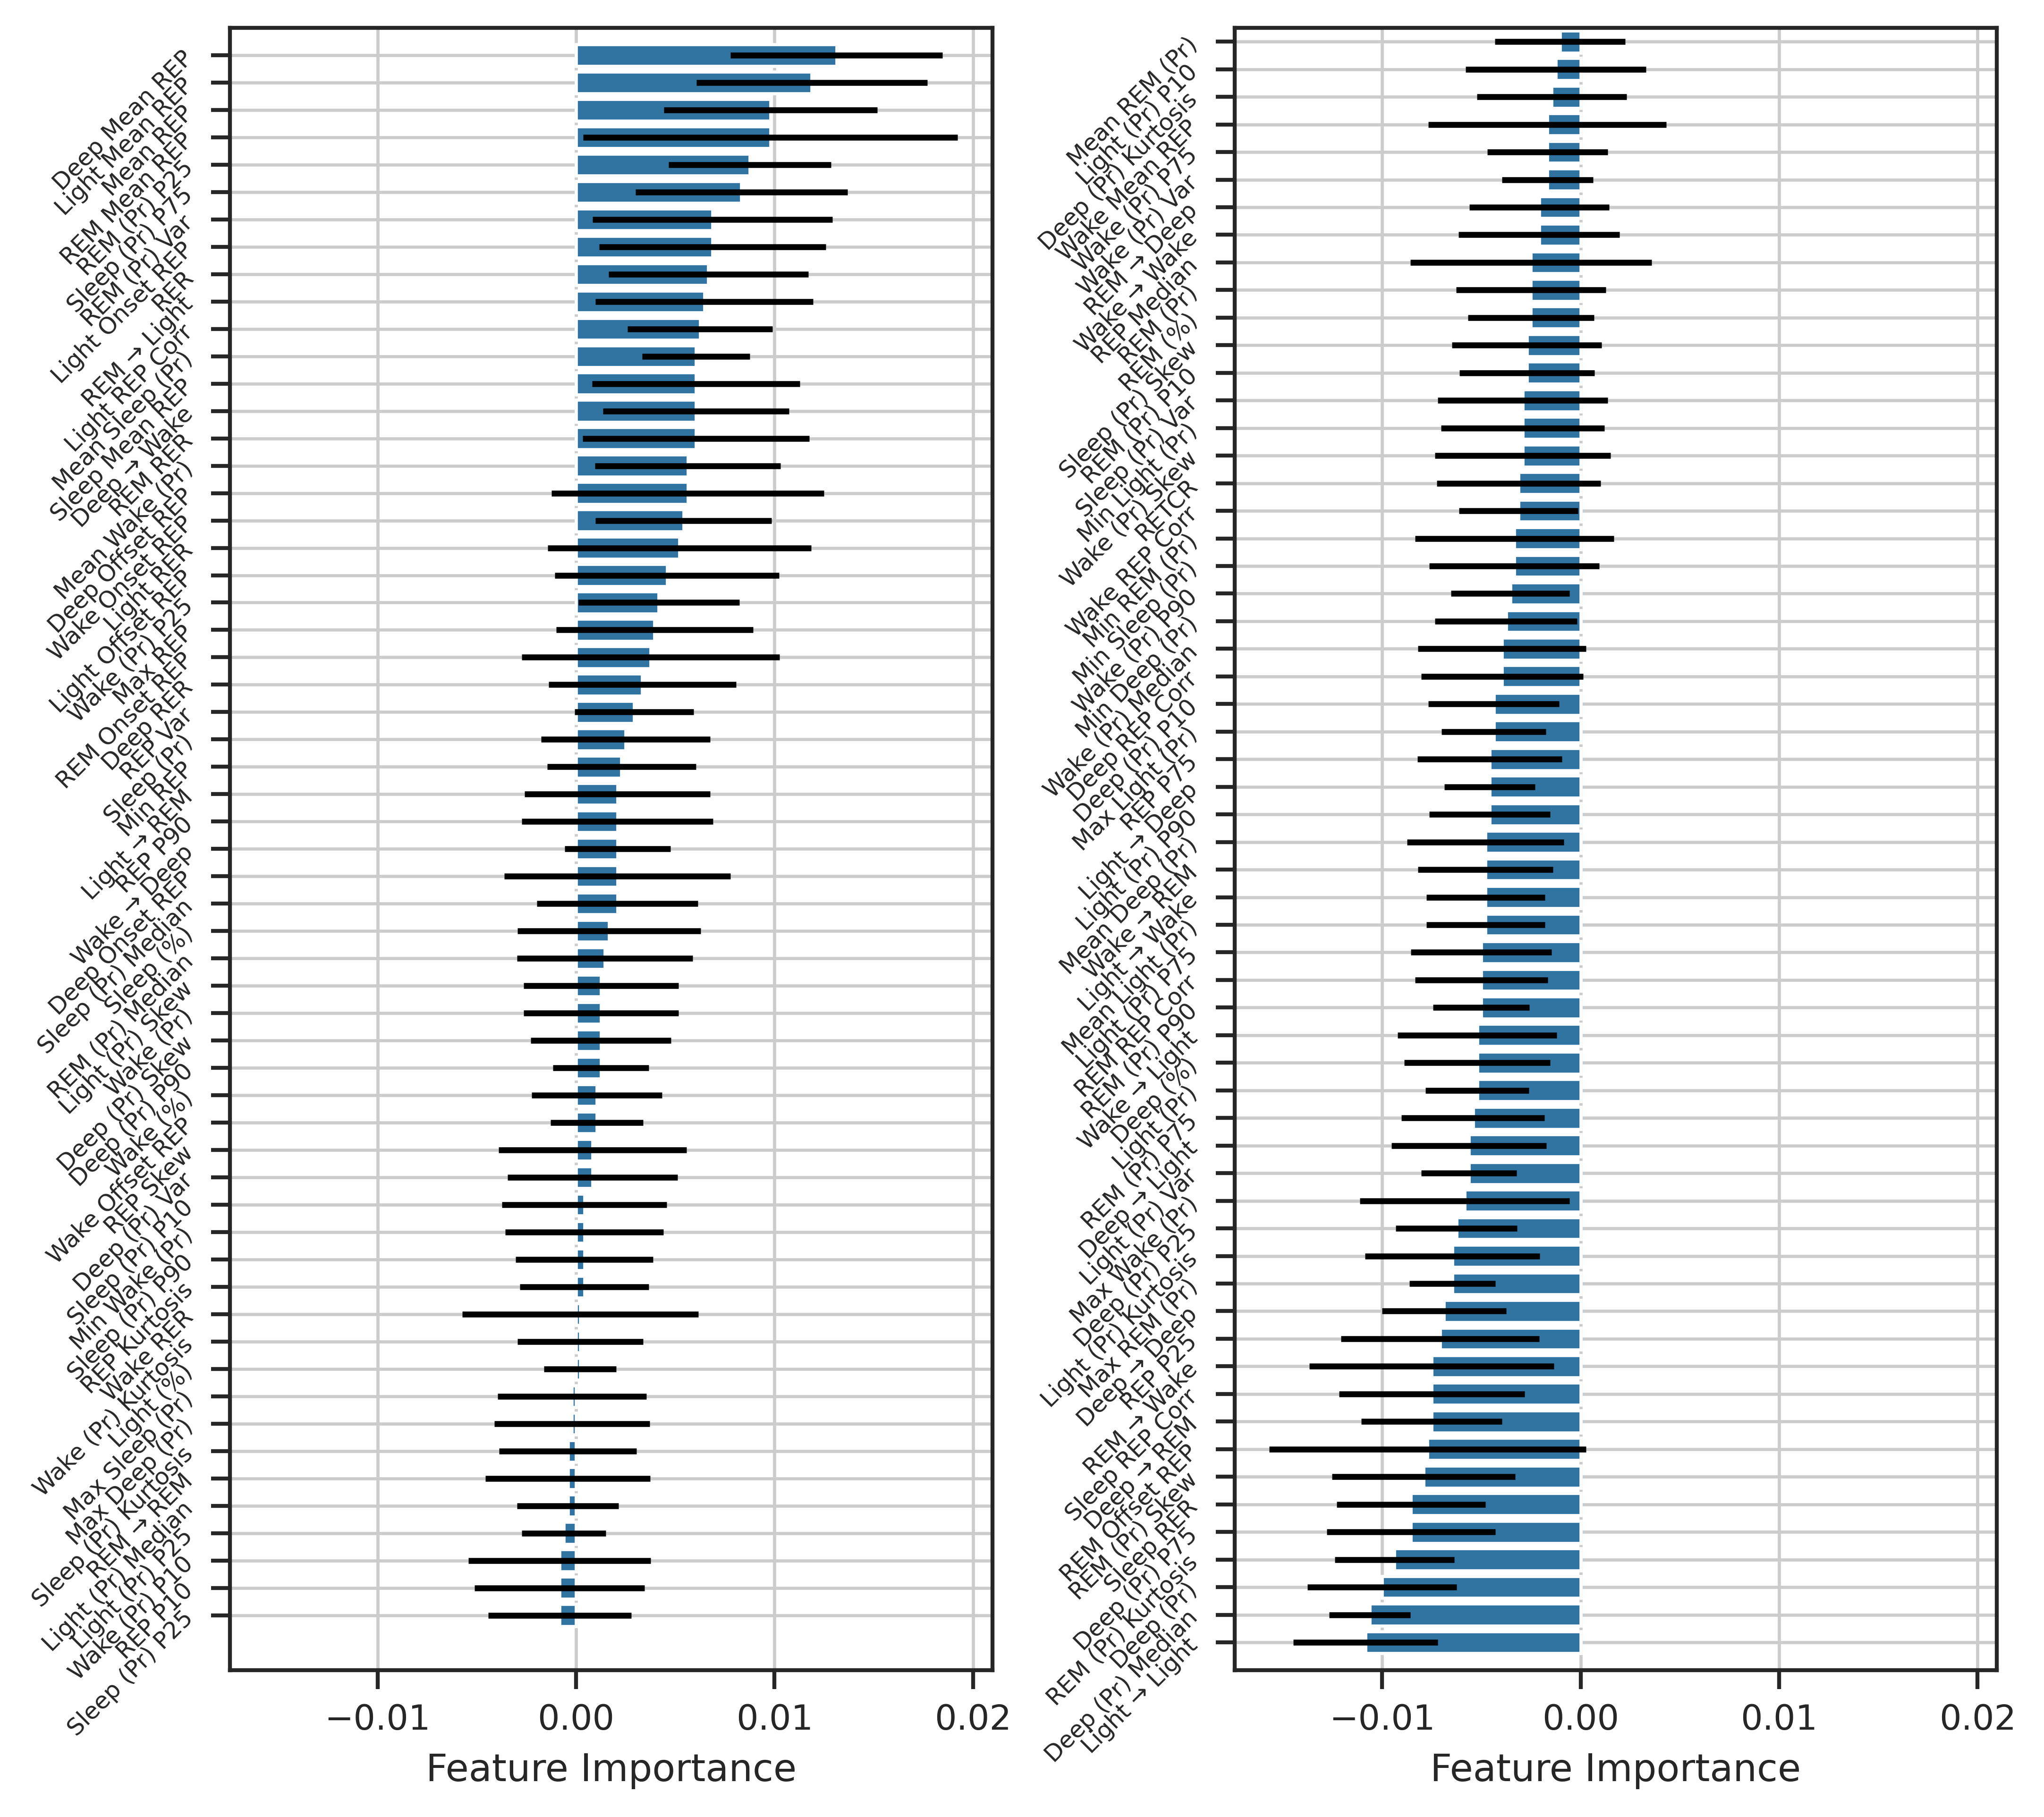

In [18]:
# Plot all feature importances
fig, axes = plt.subplots(1,2,dpi=600, figsize=(7.1,6.3), layout='constrained', sharex=True)
ax = sns.barplot(feature_importance.iloc[:len(feature_importance)//2], y='Feature', x='Feature Importance', ax=axes[0], edgecolor=None)
ax.errorbar(data=feature_importance.iloc[:len(feature_importance)//2], y='Feature', x='Feature Importance', xerr='CI_95', ls='', lw=1.5, color='black')
ax.tick_params('y',rotation = 45, labelsize=6)
for label in ax.get_yticklabels():
    label.set_horizontalalignment('right')
ax.set_ylim(len(feature_importance)//2+1, -1)
ax.set_ylabel('')
# ax.axhline(22.5, color='red')
ax.grid()

ax = sns.barplot(feature_importance.iloc[len(feature_importance)//2:], y='Feature', x='Feature Importance', ax=axes[1], edgecolor=None)
ax.errorbar(data=feature_importance.iloc[len(feature_importance)//2:], y='Feature', x='Feature Importance', xerr='CI_95', ls='', lw=1.5, color='black')
ax.tick_params('y',rotation = 45, labelsize=6)
for label in ax.get_yticklabels():
    label.set_horizontalalignment('right')
ax.set_ylim(len(feature_importance)//2+1, -0.5)
ax.set_ylabel('')
ax.grid()

plt.show()